# Get a model report

The report includes: 
- Accuracy, Precision, Recall, F1 Score, ROC-AUC, Matriz de confusion
- Graphs of train acc (%), train err (%), test acc (%) test err (%)

In [109]:
# pip install scikit-learn
import csv
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

MODEL_TAG = "efficientnetb0"

## Config

In [110]:
IMG_SIZE = 256
BATCH_SIZE = 8
THRESHOLD = 0.5 # Clase binaria (2), 0.5 es suficiente
LABEL_MODE = "binary"
CLASS_NAMES = ["no", "yes"]
TEST_DIR = Path("data/dataset_ready/test")

# Change this path when evaluating a different saved model.
MODEL_PATH = Path(f"checkpoints/{MODEL_TAG}/{MODEL_TAG}.keras")
REPORT_DIR = Path("reports") / MODEL_PATH.stem
REPORT_DIR.mkdir(parents=True, exist_ok=True)

METRICS_CSV_PATH = REPORT_DIR / "test_metrics.csv"
CLASSIFICATION_REPORT_CSV_PATH = REPORT_DIR / "classification_report.csv"
CONFUSION_MATRIX_CSV_PATH = REPORT_DIR / "confusion_matrix.csv"
CONFUSION_MATRIX_PNG_PATH = REPORT_DIR / "confusion_matrix.png"

## Load

In [111]:
loaded_model = load_model(MODEL_PATH)
loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,541,864 (17.33 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 328,196 (1.25 MB)

In [112]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode=LABEL_MODE,
    shuffle=False # Solo en test queremos evitar el shuffle, para debuggear mejor.
)

Found 51 files belonging to 2 classes.


## Test Metrics

In [113]:
# Predicciones del modelo
probs = loaded_model.predict(test_ds).ravel()

# Convertir probabilidades a clases binarias
y_pred = (probs > THRESHOLD).astype(int)

# Etiquetas reales
y_true = np.concatenate([
    labels.numpy()
    for _, labels in test_ds
]).ravel().astype(int)

# Metricas
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) else 0.0
roc_auc = roc_auc_score(y_true, probs)

metrics_dict = {
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred, zero_division=0),
    "Recall": recall_score(y_true, y_pred, zero_division=0),
    "F1 Score": f1_score(y_true, y_pred, zero_division=0),
    "Specificity": specificity,
    "ROC-AUC": roc_auc,
}

with METRICS_CSV_PATH.open("w", newline="", encoding="utf-8") as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=metrics_dict.keys()
    )
    writer.writeheader()
    writer.writerow(metrics_dict)

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

with CLASSIFICATION_REPORT_CSV_PATH.open(
    "w",
    newline="",
    encoding="utf-8"
) as csv_file:

    fieldnames = [
        "label",
        "precision",
        "recall",
        "f1-score",
    ]

    writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    writer.writeheader()

    for label, values in report_dict.items():

        if label == "accuracy":
            continue

        writer.writerow({
            "label": label,
            "precision": values.get("precision", ""),
            "recall": values.get("recall", ""),
            "f1-score": values.get("f1-score", ""),
        })

print(f"\nSaved metrics CSV to: {METRICS_CSV_PATH}")
print(f"Saved classification report CSV to: {CLASSIFICATION_REPORT_CSV_PATH}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step 

Saved metrics CSV to: reports\efficientnetb0\test_metrics.csv
Saved classification report CSV to: reports\efficientnetb0\classification_report.csv


## Confusion Matrix

|               | Predicho Negativo | Predicho Positivo |
| ------------- | ----------------- | ----------------- |
| Real Negativo | VN           | FP            |
| Real Positivo | FN        | VP          |

Saved confusion matrix plot to: reports\efficientnetb0\confusion_matrix.png


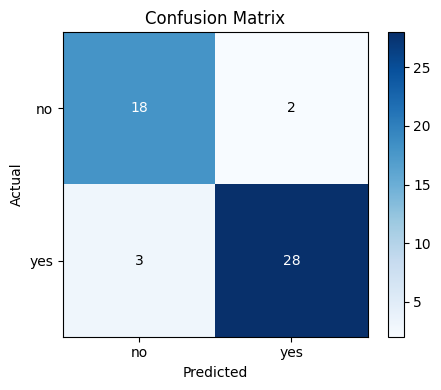

In [114]:
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)

threshold = cm.max() / 2
for row_idx in range(cm.shape[0]):
    for col_idx in range(cm.shape[1]):
        ax.text(
            col_idx,
            row_idx,
            cm[row_idx, col_idx],
            ha="center",
            va="center",
            color="white" if cm[row_idx, col_idx] > threshold else "black"
        )

fig.colorbar(image, ax=ax)
fig.tight_layout()
fig.savefig(CONFUSION_MATRIX_PNG_PATH, dpi=300, bbox_inches="tight")
print(f"Saved confusion matrix plot to: {CONFUSION_MATRIX_PNG_PATH}")
plt.show()

## Single Image Inference (from test dataset)

In [119]:
from tensorflow.keras.preprocessing import image
import random

TARGET = "no" # "yes", "no"

testTargetDir = TEST_DIR / TARGET
archivos = [str(file) for file in testTargetDir.iterdir() if file.is_file()]
img_path = random.choice(archivos)
img = image.load_img(
    img_path,
    target_size=(IMG_SIZE, IMG_SIZE)
)

x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)

prob = loaded_model.predict(x, verbose=0)[0][0]

print("Tumor probability:", prob)
if prob > 0.5:
    print("Prediction: YES (Tumor)")
else:
    print("Prediction: NO (Healthy)")
print(img_path)

Tumor probability: 0.09843535
Prediction: NO (Healthy)
data\dataset_ready\test\no\images_no_073.png


## Single Image Inference (from import)

In [ ]:
from tensorflow.keras.preprocessing import image

# img_path = Path("data/dataset_ready/test/yes/images_yes_005.png")

if not img_path.exists():
    raise FileNotFoundError(f"Image file not found: {img_path}")

img = image.load_img(
    img_path,
    target_size=(IMG_SIZE, IMG_SIZE)
)

x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)

prob = loaded_model.predict(x, verbose=0)[0][0]

print("Tumor probability:", prob)

if prob > 0.5:
    print("Prediction: YES (Tumor)")
else:
    print("Prediction: NO (Healthy)")

Tumor probability: 0.2983317
Prediction: NO (Healthy)
